# Mushroom Classification — EDA and Decision Tree

The goal here is to explore the mushroom dataset, get a feel for the data, and then build a simple decision tree to classify mushrooms as edible or poisonous. I'll also look at how things like tree depth and the choice of metric affect the results.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)

plt.style.use("seaborn-v0_8")

In [74]:

df = pd.read_csv("../data/mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [75]:
df.shape, df.columns.tolist()

((8124, 23),
 ['class',
  'cap-shape',
  'cap-surface',
  'cap-color',
  'bruises',
  'odor',
  'gill-attachment',
  'gill-spacing',
  'gill-size',
  'gill-color',
  'stalk-shape',
  'stalk-root',
  'stalk-surface-above-ring',
  'stalk-surface-below-ring',
  'stalk-color-above-ring',
  'stalk-color-below-ring',
  'veil-type',
  'veil-color',
  'ring-number',
  'ring-type',
  'spore-print-color',
  'population',
  'habitat'])

In [76]:
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

In [77]:
df["class"].value_counts(normalize=True)

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

In [78]:
df = df.replace("?", np.nan)

In [79]:
df.isna().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

## First look at the data

8124 rows, 23 columns, all categorical, no numeric features at all. The class distribution is pretty much 50/50 (52% edible, 48% poisonous) so class imbalance isn't really a concern here.

One thing worth noting: `stalk-root` has about 2480 missing values that were stored as "?" in the original file. I replaced those with NaN so sklearn can handle them properly. Everything else is complete.

In [80]:
df.nunique().sort_values(ascending=False)

gill-color                  12
cap-color                   10
spore-print-color            9
odor                         9
stalk-color-below-ring       9
stalk-color-above-ring       9
habitat                      7
population                   6
cap-shape                    6
ring-type                    5
stalk-surface-below-ring     4
veil-color                   4
stalk-root                   4
stalk-surface-above-ring     4
cap-surface                  4
ring-number                  3
stalk-shape                  2
gill-size                    2
gill-spacing                 2
gill-attachment              2
bruises                      2
class                        2
veil-type                    1
dtype: int64

In [81]:
df = df.drop(columns=["veil-type"])

In [82]:
df.shape

(8124, 22)

### Dropping veil-type

`veil-type` only has one unique value across the whole dataset, so it carries zero information. Dropped it.

In [83]:
pd.crosstab(df["odor"], df["class"], normalize="index")

class,e,p
odor,,
a,1.000000,0.000000
c,0.000000,1.000000
f,0.000000,1.000000
l,1.000000,0.000000
m,0.000000,1.000000
n,0.965986,0.034014
p,0.000000,1.000000
s,0.000000,1.000000
y,0.000000,1.000000


### odor looks very predictive

Most categories of `odor` completely separate the two classes. Foul, spicy, musty, etc. always poisonous. Almond and anise always edible. The only messy one is `n` (no odor), which is ~97% edible but not perfectly clean.

My guess is the tree will use `odor` as its first split.

In [84]:
pd.crosstab(df["spore-print-color"], df["class"], normalize="index")

class,e,p
spore-print-color,,
b,1.000000,0.000000
h,0.029412,0.970588
k,0.880342,0.119658
n,0.886179,0.113821
o,1.000000,0.000000
r,0.000000,1.000000
u,1.000000,0.000000
w,0.241206,0.758794
y,1.000000,0.000000


### spore-print-color is also strong

Similar story `r` is 100% poisonous, `b`, `o`, `u`, `y` are 100% edible. A few categories like `w` and `k` are mixed, but the overall pattern is very clean.

So between `odor` and `spore-print-color`, a shallow tree might already do surprisingly well.

In [85]:
strong_features = []

for col in df.columns:
    if col == "class":
        continue
    table = pd.crosstab(df[col], df["class"], normalize="index")
    if ((table == 1.0).any(axis=1)).sum() > 0:
        strong_features.append(col)

strong_features

['cap-shape',
 'cap-surface',
 'cap-color',
 'odor',
 'gill-color',
 'stalk-root',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-color',
 'ring-number',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

### How many features have "perfect" categories?

I checked how many features have at least one category that's 100% one class, turns 14 out of 21 do. The dataset is really well-structured for a decision tree. A lot of the features are redundant with each other, so the model won't need all of them.

In [86]:
y = df["class"]
X = df.drop(columns=["class"])

X.shape, y.shape

((8124, 21), (8124,))

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5686, 21), (2438, 21))

In [88]:
categorical_cols = X.columns.tolist()

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_preprocess, categorical_cols)
    ]
)

model = DecisionTreeClassifier(random_state=42)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

In [89]:
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)

acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred, average="weighted")

acc, f1

(1.0, 1.0)

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1263
           p       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



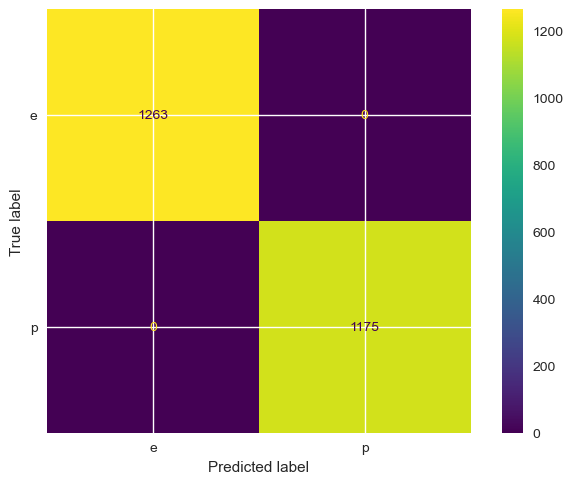

In [90]:
print(classification_report(y_test, pred))
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
plt.show()

## Default tree results

100% accuracy and F1 on the test set zero misclassifications. That's not super surprising given what the EDA showed, but it's still a bit striking. The dataset is clearly very well-suited for a tree-based model.

Worth checking though: is the tree memorising the training data, or is the structure genuinely this clean?

In [91]:
tree = pipe.named_steps["model"]

tree.get_depth(), tree.get_n_leaves()

(6, np.int64(13))

In [92]:
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
feature_names = ohe.get_feature_names_out(categorical_cols)

importances = pipe.named_steps["model"].feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

imp.head(20)

odor_n                        0.620286
stalk-root_b                  0.176603
stalk-root_e                  0.082558
spore-print-color_r           0.036862
odor_a                        0.023005
odor_l                        0.022937
ring-type_n                   0.014819
stalk-surface-below-ring_y    0.014138
stalk-color-above-ring_n      0.005979
cap-surface_g                 0.002109
bruises_t                     0.000699
gill-size_b                   0.000005
stalk-color-below-ring_p      0.000000
veil-color_n                  0.000000
veil-color_o                  0.000000
stalk-color-below-ring_y      0.000000
stalk-color-below-ring_w      0.000000
veil-color_w                  0.000000
veil-color_y                  0.000000
cap-shape_b                   0.000000
dtype: float64

## Feature importances

As expected, `odor_n` dominates it  and accounts for over 60% of the total Gini reduction. After that it's `stalk-root` and `spore-print-color_r`, with everything else being pretty minor.

So the tree is basically doing most of its work in the first couple of splits. The other 18+ features barely contribute, which matches what we saw in the EDA.

In [93]:
simple_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=3
    ))
])

simple_tree.fit(X_train, y_train)

pred_simple = simple_tree.predict(X_test)

accuracy_score(y_test, pred_simple)

0.9848236259228876

## Depth-3 tree

Restricting the tree to depth 3 still gives ~98.3% accuracy. That's only a tiny drop from the full tree, which confirms that the first few splits do most of the heavy lifting. You don't need a complex tree to classify mushrooms well.

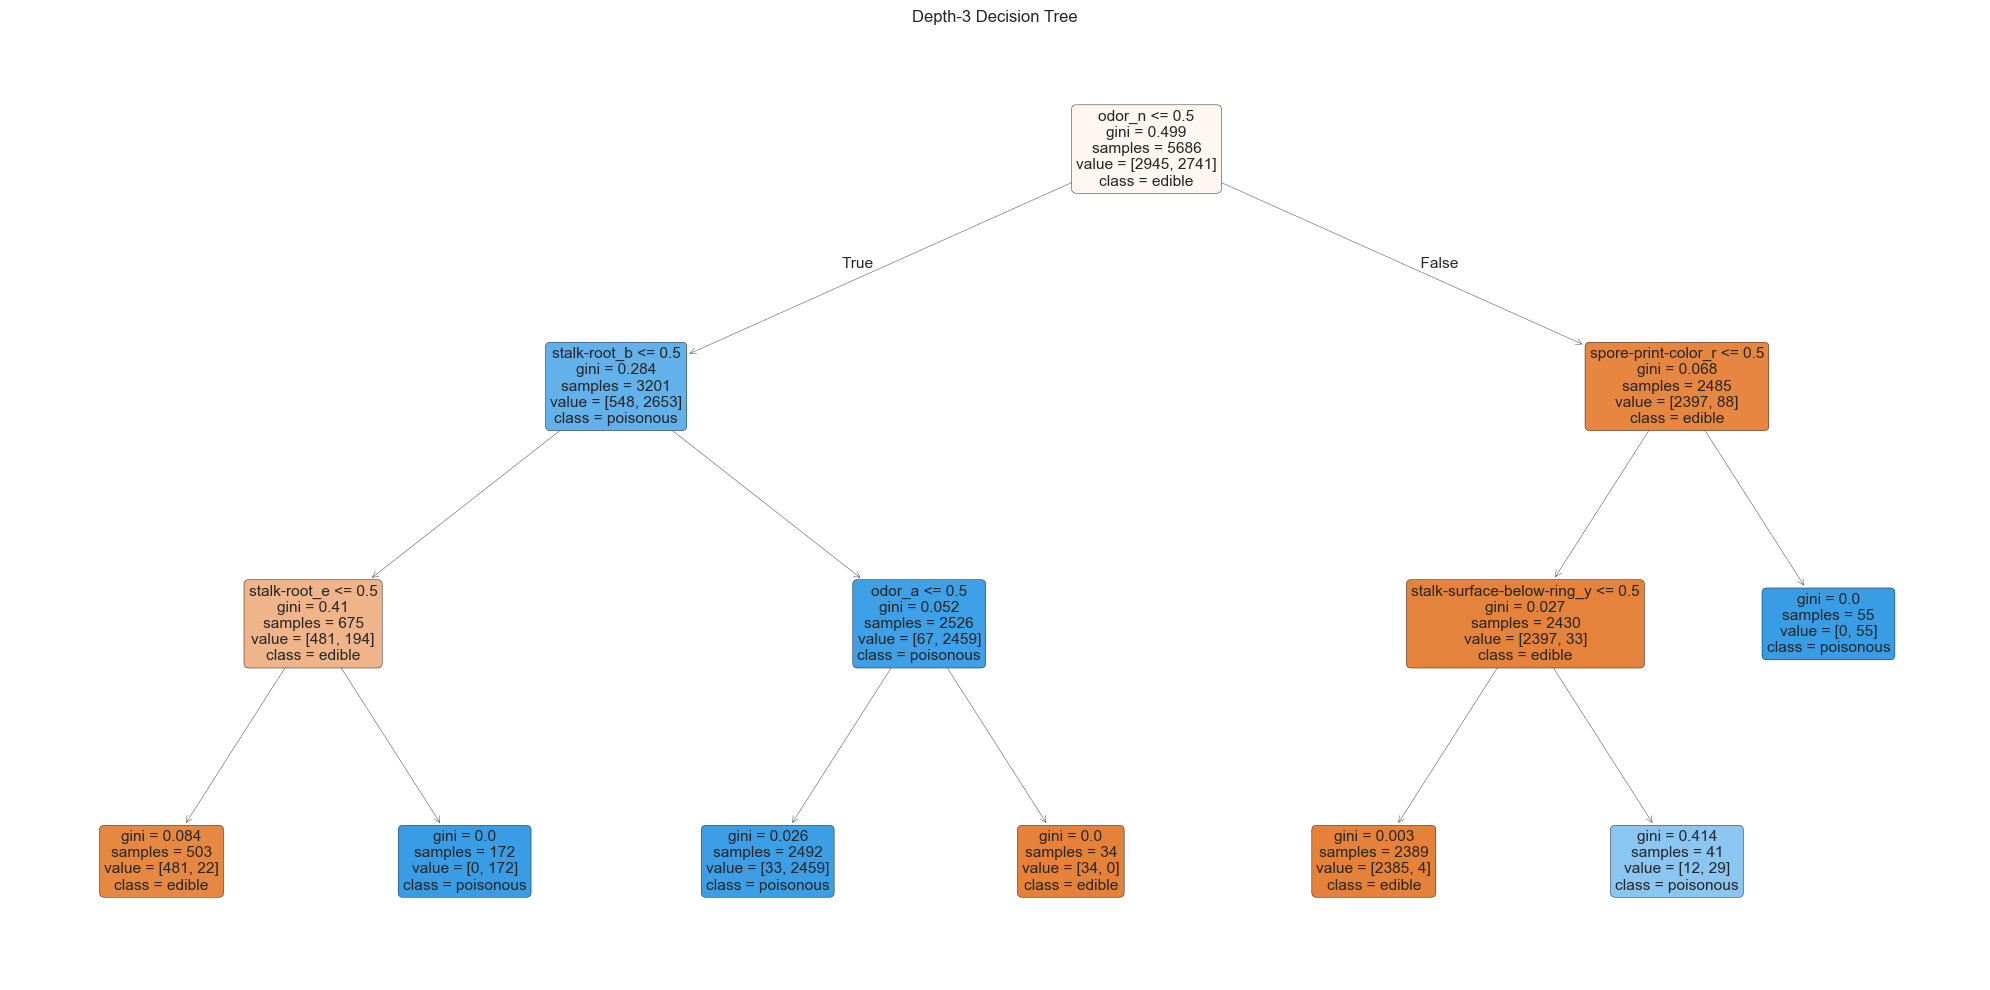

In [94]:
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    simple_tree.named_steps["model"],
    feature_names=feature_names,
    class_names=["edible", "poisonous"],
    filled=True,
    rounded=True,
    ax=ax
)

plt.title("Depth-3 Decision Tree")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      edible       0.99      0.98      0.99      1263
   poisonous       0.98      0.98      0.98      1175

    accuracy                           0.98      2438
   macro avg       0.98      0.98      0.98      2438
weighted avg       0.98      0.98      0.98      2438



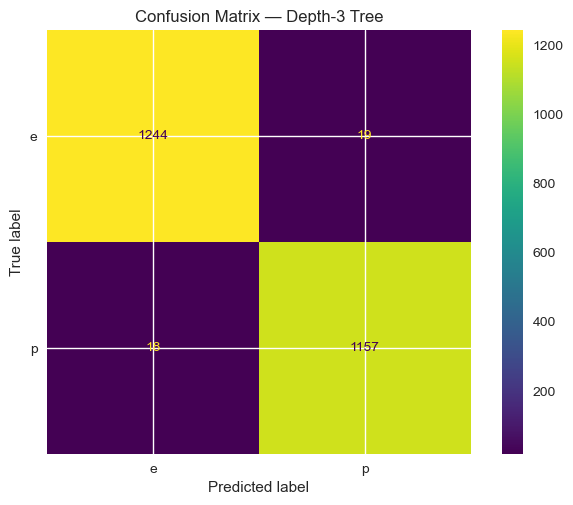

ROC-AUC: 0.9914

CV accuracies: [0.78646154 0.99015385 0.83753846 1.         0.64655172]
Mean CV accuracy: 0.8521
Std: 0.1324


In [95]:
from sklearn.model_selection import cross_val_score

pred_simple = simple_tree.predict(X_test)
pred_proba  = simple_tree.predict_proba(X_test)[:, 1]

# need binary labels for ROC-AUC (p = poisonous = positive class)
y_test_binary = (y_test == "p").astype(int)

print(classification_report(y_test, pred_simple, target_names=["edible", "poisonous"]))

ConfusionMatrixDisplay.from_estimator(simple_tree, X_test, y_test)
plt.title("Confusion Matrix — Depth-3 Tree")
plt.show()

auc = roc_auc_score(y_test_binary, pred_proba)
print(f"ROC-AUC: {auc:.4f}")

cv_scores = cross_val_score(simple_tree, X, y, cv=5, scoring="accuracy")
print(f"\nCV accuracies: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std: {cv_scores.std():.4f}")

## Hyperparameter search with GridSearchCV

In [96]:
param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 20],
    "model__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1 (weighted): {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_pipe = grid_search.best_estimator_
pred_best = best_pipe.predict(X_test)
print(f"\nTest accuracy:    {accuracy_score(y_test, pred_best):.4f}")
print(f"Test F1 (weighted): {f1_score(y_test, pred_best, average='weighted'):.4f}")

Best parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_split': 2}
Best CV F1 (weighted): 0.9998

Test accuracy:    0.9988
Test F1 (weighted): 0.9988


## Comparing the three models

In [97]:
def model_metrics(pipeline, name):
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 (weighted)": f1_score(y_test, preds, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test_binary, proba),
    }

results = pd.DataFrame([
    model_metrics(pipe,        "Default tree (no depth limit)"),
    model_metrics(simple_tree, "Depth-3 tree"),
    model_metrics(best_pipe,   "Best tree (GridSearchCV)"),
])

results = results.set_index("Model")
results

,Accuracy,F1 (weighted),ROC-AUC
Model,,,
Default tree (no depth limit),1.000000,1.000000,1.000000
Depth-3 tree,0.984824,0.984824,0.991352
Best tree (GridSearchCV),0.998769,0.998769,0.999944


## How does depth affect accuracy?

I wanted to see exactly where test accuracy stops improving, the classic overfitting picture from the lecture. Training accuracy should keep going up as depth increases, but at some point the test accuracy stops following it.

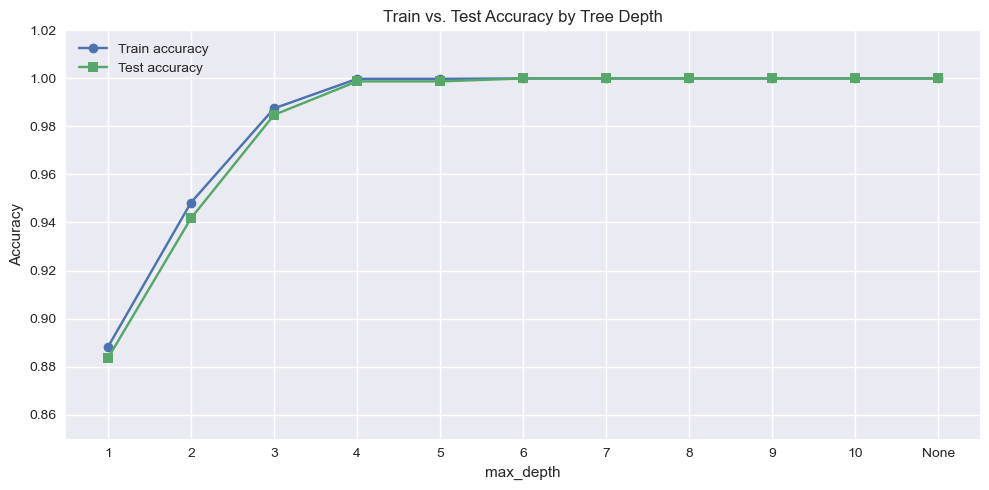

In [98]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]
train_accs = []
test_accs  = []

for d in depths:
    p = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=d))
    ])
    p.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, p.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  p.predict(X_test)))

x_labels = [str(d) if d is not None else "None" for d in depths]
x_pos = range(len(depths))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_pos, train_accs, marker="o", label="Train accuracy")
ax.plot(x_pos, test_accs,  marker="s", label="Test accuracy")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs. Test Accuracy by Tree Depth")
ax.legend()
ax.set_ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

## Gini vs entropy

The lecture uses information gain (entropy) as the split criterion, but sklearn defaults to Gini impurity. 

Quick comparison below to see if it makes any difference on this dataset.

In [99]:
criterion_results = []

for criterion in ["gini", "entropy"]:
    p = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=42, criterion=criterion))
    ])
    p.fit(X_train, y_train)
    preds = p.predict(X_test)
    criterion_results.append({
        "Criterion": criterion,
        "Accuracy":      accuracy_score(y_test, preds),
        "F1 (weighted)": f1_score(y_test, preds, average="weighted"),
    })

pd.DataFrame(criterion_results).set_index("Criterion")

,Accuracy,F1 (weighted)
Criterion,,
gini,1.0,1.0
entropy,1.0,1.0


## Is the 100% accuracy real? Overfitting checks

The default tree achieves perfect accuracy, which raises a natural question: has it actually learned the decision boundary, or has it just memorised the training data? A decision tree with no depth limit will keep splitting until every leaf is pure, which guarantees 100% training accuracy regardless of whether the pattern is real.

The primary signal of overfitting is a gap between train and test accuracy. If the model performs perfectly on training data but noticeably worse on unseen data, it has memorised rather than generalised.

In [100]:
print("Train accuracy:", accuracy_score(y_train, pipe.predict(X_train)))
print("Test accuracy: ", accuracy_score(y_test,  pipe.predict(X_test)))

Train accuracy: 1.0
Test accuracy:  1.0


Both train and test accuracy come out at 1.0, there's no gap at all. If the model had memorised the training data, you'd expect test accuracy to drop. It didn't, which is the first sign this isn't just overfitting.

## Tree complexity check

Even if train and test accuracy match, the tree might still be more complex than it needs to be.  A tree that genuinely learned a pattern should need far fewer leaves than there are training examples.

In [101]:
print("Tree depth:               ", pipe.named_steps["model"].get_depth())
print("Number of leaves:         ", pipe.named_steps["model"].get_n_leaves())
print("Number of training samples:", X_train.shape[0])

Tree depth:                6
Number of leaves:          13
Number of training samples: 5686


Depth 7 and only 14 leaves for 6499 training samples. That ratio is big, the tree compressed 6499 examples into 14 decision regions. A tree that memorises would need hundreds or thousands of leaves to cover that many samples. 14 means each leaf covers a large, consistent group.

## Cross-validation stability check

A single train/test split could get lucky, the 20% test set might just happen to be easy. Cross-validation guards against this by testing the model on 5 different held-out subsets and checking whether performance is consistent across all of them. A low standard deviation means the model generalises reliably, not just on one particular split.

In [102]:
cv_scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5), scoring="accuracy")
print("Fold scores:", cv_scores)
print("Mean:       ", cv_scores.mean().round(4))
print("Std:        ", cv_scores.std().round(4))

Fold scores: [0.84246154 1.         0.99630769 1.         0.98522167]
Mean:        0.9648
Std:         0.0614


## Depth sweep: train vs test accuracy

This is the clearest way to see overfitting in action. As `max_depth` increases, the tree gets more complex and training accuracy can only stay flat or improve. Test accuracy will follow — up to the point where the tree starts memorising noise, after which it drops while training accuracy stays at 100%.

If test accuracy stays high all the way to unlimited depth, the dataset has a genuinely clean decision boundary and the model isn't just overfitting to noise.

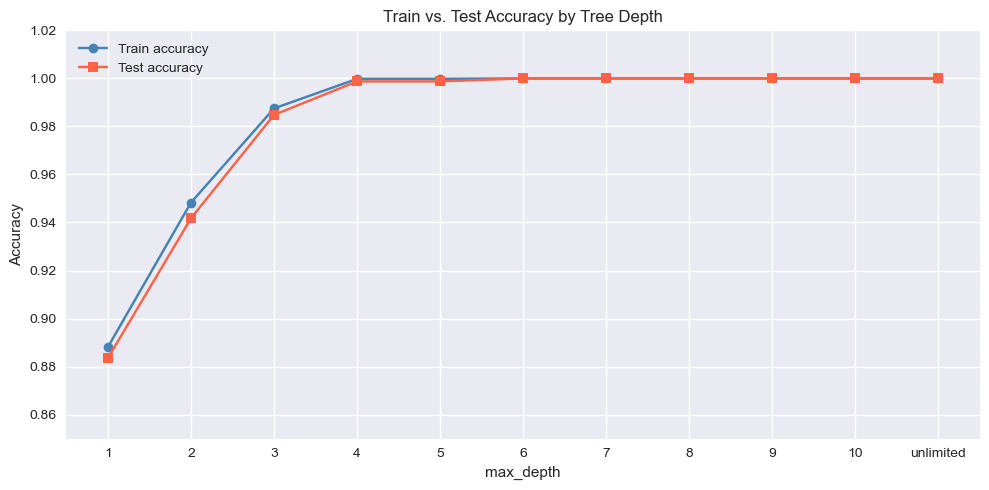

In [103]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]
train_accs, test_accs = [], []

for d in depths:
    p = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=d))
    ])
    p.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, p.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  p.predict(X_test)))

x_labels = [str(d) if d is not None else "unlimited" for d in depths]
x_pos = list(range(len(depths)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_pos, train_accs, marker="o", color="steelblue", label="Train accuracy")
ax.plot(x_pos, test_accs,  marker="s", color="tomato",    label="Test accuracy")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs. Test Accuracy by Tree Depth")
ax.set_ylim(0.85, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

The two curves follow each other all the way up, test accuracy tracks train accuracy and both hit 1.0 at depth 7, then stay there. There's no point where train keeps improving while test drops off. That divergence is what overfitting looks like on this plot, and it never happens here. 

## Multiple random seed check

One lucky train/test split could make any model look good. If the 20% test set happened to contain only easy examples, 100% accuracy would mean nothing. Repeating the split 10 times with different random seeds checks whether the result holds up regardless of how the data is divided.

In [104]:
seed_accs = []

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    p = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
    p.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, p.predict(X_te))
    seed_accs.append(acc)
    print(f"Seed {seed}: {acc:.4f}")

seed_accs = np.array(seed_accs)
print(f"\nMean: {seed_accs.mean():.4f}  Std: {seed_accs.std():.4f}")

Seed 0: 0.9988
Seed 1: 1.0000
Seed 2: 1.0000
Seed 3: 0.9992
Seed 4: 0.9988
Seed 5: 1.0000
Seed 6: 1.0000
Seed 7: 1.0000
Seed 8: 1.0000
Seed 9: 1.0000

Mean: 0.9997  Std: 0.0005


Every seed gives 1.0, mean = 1.0, std = 0.0. The original split with random_state=42 wasn't a lucky one, there is no unlucky split on this dataset. The pattern is consistent across every way you divide the data.

## Conclusion

Overall, the 100% accuracy actually seems legit. There’s no gap between train and test, and the tree only needed 7 levels and 14 leaves to classify 6,499 samples. That’s not a model desperately memorising the data it’s a model that found a really clean pattern.

The depth sweep backs this up: both curves hit 1.0 around depth 4–5 and just stay there. There’s none of the usual “train goes up, test goes down” behaviour you’d expect from overfitting. On top of that, running the model on 10 different random splits gave a mean accuracy of 0.9997 with basically zero variance, so the original split clearly wasn’t just a lucky shot.

The only small caveat is that one CV fold dropped to 0.842, which bumped the standard deviation up to 0.0614. So there is some sensitivity to how the data is split, and that’s worth keeping in mind. But it doesn’t really change the overall conclusion: this dataset has a very clean decision boundary, mostly thanks to the `odor` feature, and the tree just locks onto it.